In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

2026-03-09 11:10:20.878476: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 11:10:20.878895: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-09 11:10:20.881205: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-09 11:10:20.887330: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773025820.897739  143806 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773025820.90

# Specify each path

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keyp/keypoint_classifier.h5'
tflite_save_path = 'model/keyp/keypoint_classifier.tflite'

# Set number of classes

In [3]:
NUM_CLASSES = 5

# Dataset reading

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

In [7]:
print('X_dataset shape:', X_dataset.shape)
print('y_dataset shape:', y_dataset.shape)
unique_labels, counts = np.unique(y_dataset, return_counts=True)
print('Class distribution:', dict(zip(unique_labels.tolist(), counts.tolist())))

X_dataset shape: (3505, 42)
y_dataset shape: (3505,)
Class distribution: {0: 1522, 1: 1572, 2: 411}


# Model building

Set `use_lstm = True` in the next cell to switch from the default MLP to an LSTM-based model over the 21 hand landmarks.

In [8]:
use_lstm = True
model = None

if use_lstm:
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(21 * 2,)),
        tf.keras.layers.Reshape((21, 2)),
        
        # 移除 Bidirectional，改回單向 LSTM 
        # 並加上 unroll=True (這能幫助 TFLite 靜態展開，大幅提高轉換成功率)
        tf.keras.layers.LSTM(64, return_sequences=False, unroll=True), 
        
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
        ])
else:
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input((21 * 2, )),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(20, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(10, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])

E0000 00:00:1773025822.821182  143806 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773025822.823255  143806 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [9]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 21, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,653 (76.77 KB)

 Trainable params: 19,525 (76.27 KB)

 Non-trainable params: 128 (512.00 B)

In [10]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [11]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [12]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
16/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2862 - loss: 1.6921
Epoch 1: saving model to model/keyp/keypoint_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4285 - loss: 1.4226 - val_accuracy: 0.5735 - val_loss: 1.4839
Epoch 2/1000
16/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5852 - loss: 1.0559
Epoch 2: saving model to model/keyp/keypoint_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5959 - loss: 0.9995 - val_accuracy: 0.6556 - val_loss: 1.3814
Epoch 3/1000
17/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6340 - loss: 0.8725
Epoch 3: saving model to model/keyp/keypoint_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6492 - loss: 0.8370 - val_accuracy: 0.6123 - val_loss: 1.2922
Epoch 4/1000
17/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6789 - loss: 0.7744
Epoch 4: saving model to model/keyp/keypoint_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6918 - loss: 0.7322 - val_accuracy: 0.6602 - val_loss: 1.2099
Epoch 5/1000
17/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7425 - loss: 0.6296
Epoch 5: saving model to model/keyp/keypoint_classifier.h5


...

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9954 - loss: 0.0122 - val_accuracy: 0.9943 - val_loss: 0.0229
Epoch 139/1000
17/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9928 - loss: 0.0224
Epoch 139: saving model to model/keyp/keypoint_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9943 - loss: 0.0177 - val_accuracy: 0.9897 - val_loss: 0.0317
Epoch 140/1000
15/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9955 - loss: 0.0145
Epoch 140: saving model to model/keyp/keypoint_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9947 - loss: 0.0154 - val_accuracy: 0.9932 - val_loss: 0.0255
Epoch 141/1000
15/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9958 - loss: 0.0121
Epoch 141: saving model to model/keyp/keypoint_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9954 - loss: 0.0153 - val_accuracy: 0.9932 - val_loss: 0.0232
Epoch 142/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9958 - loss: 0.0126
Epoch 142: saving model to model/keyp/keypoint_classifier.h5


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9958 - loss: 0.0133 - val_accuracy: 0.9966 - val_loss: 0.0251
Epoch 142: early stopping


In [13]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9966 - loss: 0.0251 


In [14]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [15]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
[1.2280983e-06 5.1900719e-09 9.9999881e-01 6.3762455e-12 2.6464999e-09]
2


# Confusion matrix

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


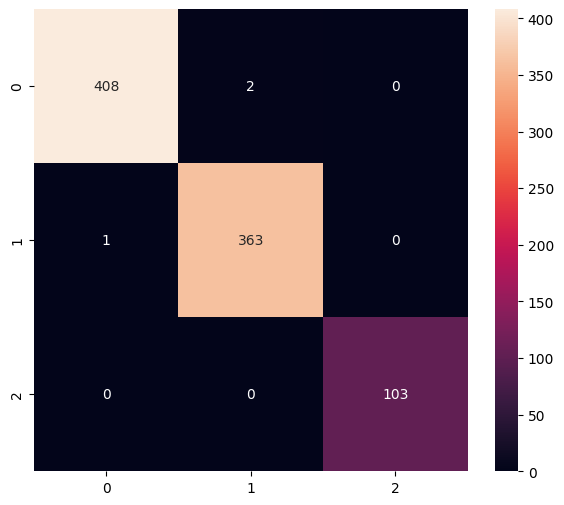

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       410
           1       0.99      1.00      1.00       364
           2       1.00      1.00      1.00       103

    accuracy                           1.00       877
   macro avg       1.00      1.00      1.00       877
weighted avg       1.00      1.00      1.00       877



In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [17]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [18]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /tmp/tmp_9vf_5c6/assets


INFO:tensorflow:Assets written to: /tmp/tmp_9vf_5c6/assets


Saved artifact at '/tmp/tmp_9vf_5c6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  124898522758336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124898191197632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124898523509360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124898191384016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124898191388064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124898191385776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124898191386832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124898189823488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124898189822080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124898189828592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  124898189829296: TensorS

W0000 00:00:1773025863.484853  143806 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1773025863.484866  143806 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-03-09 11:11:03.485086: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp_9vf_5c6
2026-03-09 11:11:03.485804: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-09 11:11:03.485810: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp_9vf_5c6
I0000 00:00:1773025863.494097  143806 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2026-03-09 11:11:03.494896: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-09 11:11:03.529145: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp_9vf_5c6
2026-03-09 11:11:03.543934: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

86912

# Inference test

In [19]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

/home/ocarpan/Documents/hand-gesture-recognition-mediapipe/venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [20]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [21]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [22]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 18 μs, sys: 849 μs, total: 867 μs
Wall time: 394 μs


In [23]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[1.0008966e-06 5.1564752e-09 9.9999905e-01 5.7797517e-12 2.3724345e-09]
2
